In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
gistemp = pd.read_csv("../data/raw/tas_GISTEMP.csv")

gistemp.head()

ParserError: Error tokenizing data. C error: Expected 4 fields in line 9, saw 6


In [6]:
noaa = pd.read_csv("../data/raw/tas_NOAAGlobalTemp.csv")
hadcrut = pd.read_csv("../data/raw/tas_HadCRUT5.csv")
berkeley = pd.read_csv("../data/raw/tas_Berkeley_Earth.csv")

ParserError: Error tokenizing data. C error: Expected 4 fields in line 9, saw 6


In [7]:
with open("../data/raw/tas_GISTEMP.csv", "r", encoding="utf-8") as f:
    for i in range(20):
        print(f.readline().strip())

Conventions,G,BADC-CSV,1
title,G,Global mean temperature
last_revised_date,G,2023-03-03
date_valid,G,2023-03-03
feature_type,G,area average
creator,G,WMO
source,G,Produced by climind version 0.1
observation_station,G,derived data
location,G,90.,-180.,-90.,180.
activity,G,WMO
history,G,"Data set created from file ['GLB.Ts+dSST.csv'] downloaded from ['https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'] at ['2023-02-27 09:16:55']"
history,G,"Rebaselined to 1981-2010 for each month separately by calculating the arithmetic mean of the data over the baseline period and subtracting the mean from all data values. This is done for each month separately (Januarys, Februarys etc)."
history,G,"Calculated annual average from monthly averages using arithmetic mean"
history,G,"Selected years within the range 1850 to 2022."
history,G,"Added offset of 0.69 to all data values."
history,G,"Manually changed baseline to 1850-1900. Note that data values remain unchanged."
reference,G,"Lenssen,

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = Path("../data/raw")


def load_badc_csv(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.strip().lower() == "data":
            data_start = i + 1
            break

    if data_start is None:
        raise ValueError(f"Could not find 'data' section in {file_path}")

    df = pd.read_csv(file_path, skiprows=data_start)

    # clean column names
    df.columns = [col.strip().lower() for col in df.columns]

    # keep only useful columns if they exist
    keep_cols = [col for col in ["year", "data"] if col in df.columns]
    df = df[keep_cols].copy()

    # convert types
    for col in keep_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna().copy()
    df["year"] = df["year"].astype(int)

    return df

In [9]:
gistemp = load_badc_csv(DATA_DIR / "tas_GISTEMP.csv")
noaa = load_badc_csv(DATA_DIR / "tas_NOAAGlobalTemp.csv")
hadcrut = load_badc_csv(DATA_DIR / "tas_HadCRUT5.csv")
berkeley = load_badc_csv(DATA_DIR / "tas_Berkeley_Earth.csv")
era5 = load_badc_csv(DATA_DIR / "tas_ERA5.csv")
jra55 = load_badc_csv(DATA_DIR / "tas_JRA-55.csv")

In [10]:
gistemp.head()

,year,data
0,1880,0.0988
1,1881,0.1829
2,1882,0.1562
3,1883,0.0929
4,1884,-0.0154


In [11]:
gistemp.info()

<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    143 non-null    int64  
 1   data    143 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


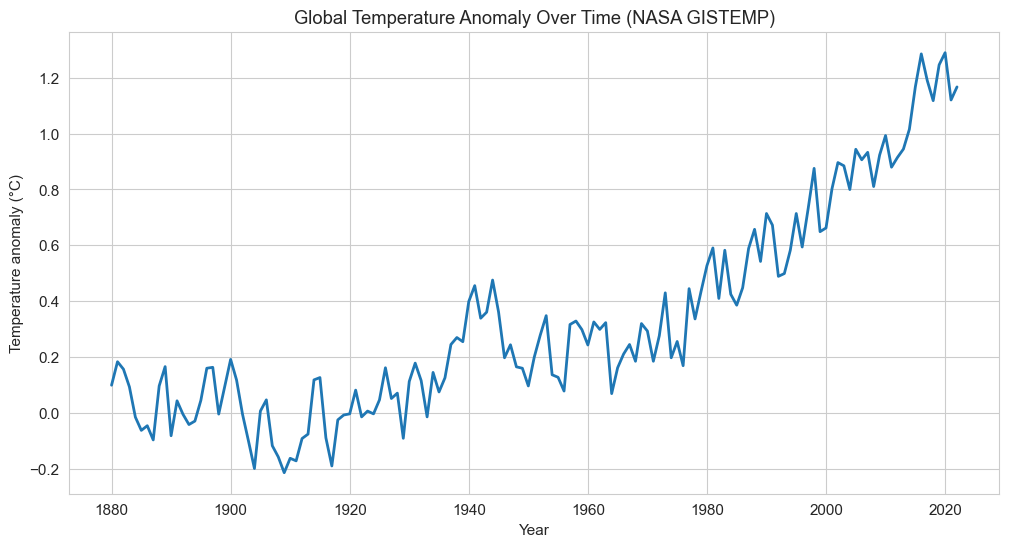

In [12]:
plt.figure()
plt.plot(gistemp["year"], gistemp["data"], linewidth=2)
plt.title("Global Temperature Anomaly Over Time (NASA GISTEMP)")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.show()

### Global Temperature Anomaly Over Time (GISTEMP)

This graph shows the evolution of global temperature anomalies based on NASA’s GISTEMP dataset. A temperature anomaly represents how much warmer or cooler a given year is compared to a historical baseline average. The chart reveals a clear upward trend in global temperatures over time, particularly from the late 20th century onwards. This pattern highlights the ongoing warming of the planet, which is widely associated with increased greenhouse gas emissions and human-driven climate change.

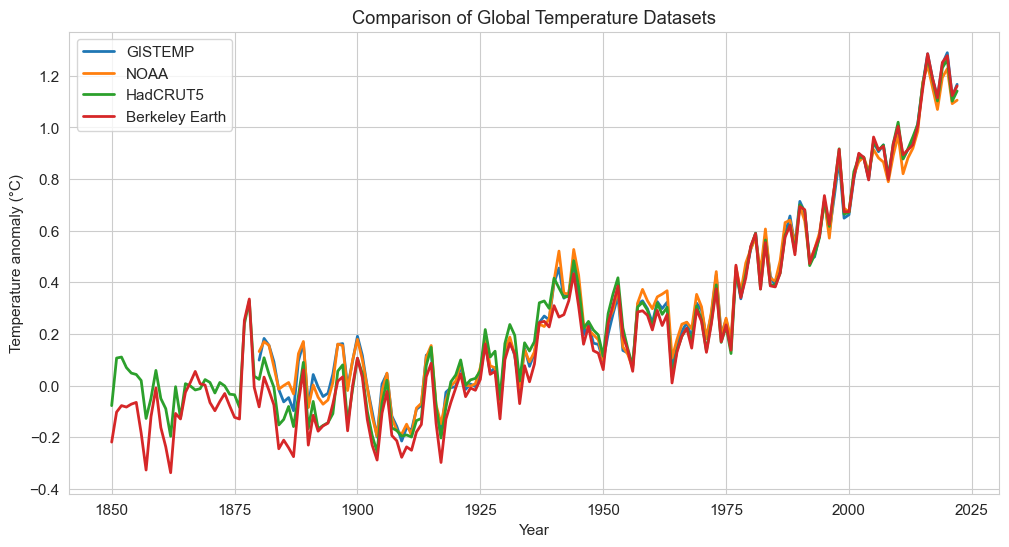

In [13]:
plt.figure()

plt.plot(gistemp["year"], gistemp["data"], label="GISTEMP", linewidth=2)
plt.plot(noaa["year"], noaa["data"], label="NOAA", linewidth=2)
plt.plot(hadcrut["year"], hadcrut["data"], label="HadCRUT5", linewidth=2)
plt.plot(berkeley["year"], berkeley["data"], label="Berkeley Earth", linewidth=2)

plt.title("Comparison of Global Temperature Datasets")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.legend()
plt.show()

### Comparison of Global Temperature Datasets

This graph compares several independent global temperature datasets, including NASA GISTEMP, NOAA GlobalTemp, HadCRUT5, and Berkeley Earth. Although these datasets are produced by different scientific organizations and rely on different methodologies, they all show a very similar upward trend. The strong agreement between these datasets reinforces the scientific consensus that the Earth's climate has been warming significantly over the past century.

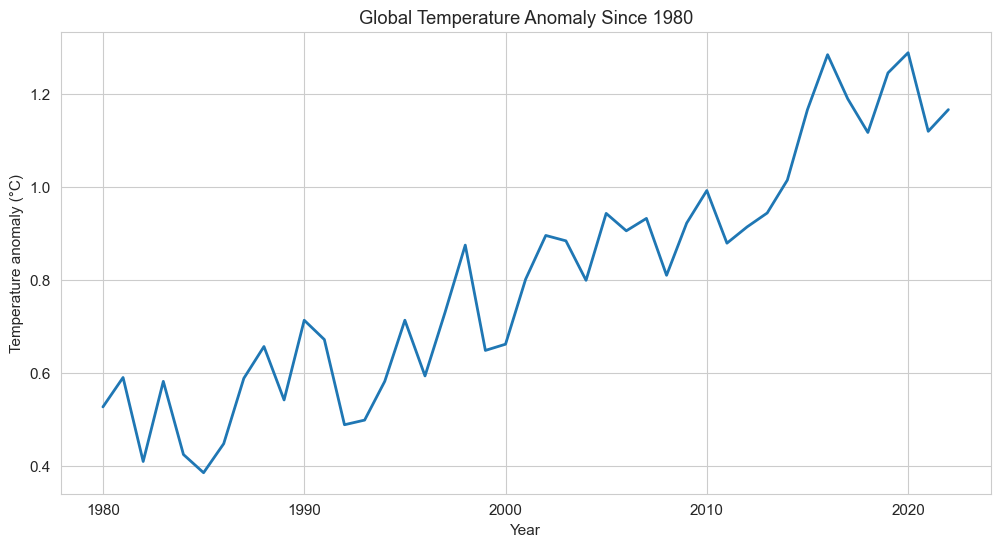

In [14]:
recent = gistemp[gistemp["year"] >= 1980].copy()

plt.figure()
plt.plot(recent["year"], recent["data"], linewidth=2)
plt.title("Global Temperature Anomaly Since 1980")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.show()

### Global Temperature Anomaly Since 1980

This chart focuses on global temperature anomalies from 1980 onward, highlighting the acceleration of global warming in recent decades. The steady increase shown in the graph indicates that global temperatures have risen rapidly over the past forty years. This period coincides with growing industrialization, increased energy consumption, and rising concentrations of greenhouse gases in the atmosphere.

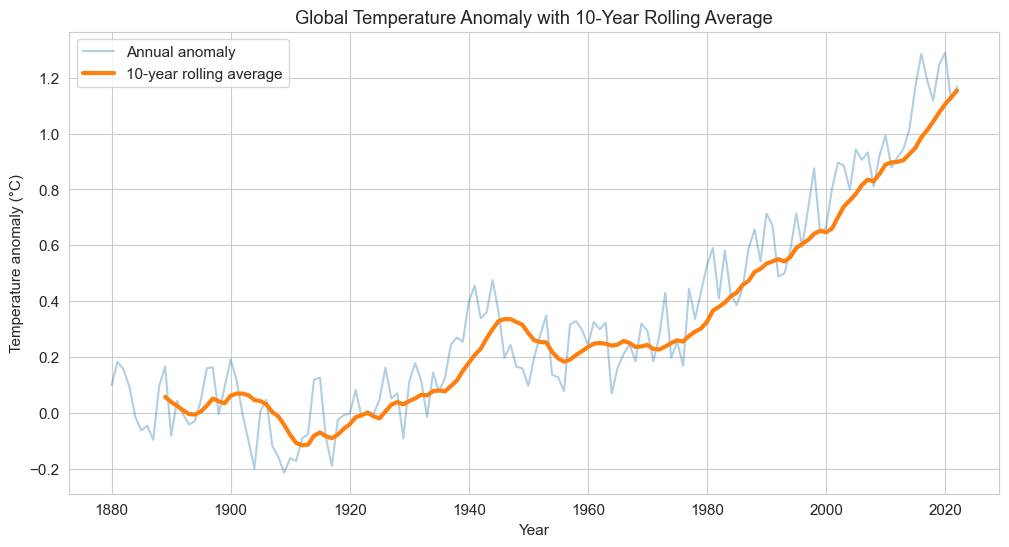

In [15]:
gistemp["rolling_10"] = gistemp["data"].rolling(10).mean()

plt.figure()
plt.plot(gistemp["year"], gistemp["data"], alpha=0.35, label="Annual anomaly")
plt.plot(gistemp["year"], gistemp["rolling_10"], linewidth=3, label="10-year rolling average")

plt.title("Global Temperature Anomaly with 10-Year Rolling Average")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.legend()
plt.show()

### Temperature Anomaly with 10-Year Rolling Average

This graph presents global temperature anomalies together with a 10-year rolling average, which smooths short-term fluctuations in the data. Individual years may vary due to natural climate variability such as El Niño events or volcanic activity. However, the rolling average highlights the long-term warming trend, making the sustained increase in global temperatures over recent decades even more apparent.